# 01. 系統横断 epitope 転用可能性マップ（Fig4）

**問い**：ある系統でA薬が作る糖鎖エピトープ状態は、別系統ではどの薬が作るか？
近ければ、そのエピトープを狙う手段（レクチン検出・抗体・ADC）は系統を越えて転用できる。

## 設計

```
点      : 承認薬 × 細胞株10（細胞内センタリング後のエピトープ変化ベクトル）
背景    : がん適応の承認薬 59/細胞 = Tier2「抗腫瘍薬の雲」
旗      : 系統一致の承認薬 16     = Tier1「その系統の薬はここ」
候補    : 非がん承認薬 343
内部対照: 同一薬ペア（同じ薬・違う細胞）の距離分布
外部対照: ランダム推論遺伝子セット / ランドマーク空間の距離
```

**主張の形**：`d(薬X@系統a, 薬Y@系統b) < d(薬X@系統a, 薬X@系統b)`
= 細胞コンテキストの差を、化合物の入れ替えで打ち消せる。

**注意**：エピトープ辞書57遺伝子のうちL1000ランドマークは3個（EXT1/FUT1/ST3GAL5）のみで、
残りは推論値。「近さが推論モデルの副産物でない」ことを §6・§7 の対照で潰す。

関連: `docs/paper_value.md`（North Star）, `docs/epitope_potential_design.md`（スコア設計）

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector as sc

plt.rcParams['font.family'] = ['Hiragino Sans', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42   # 日本語グリフをTrueTypeで埋め込む（Type3だとPDF出力が落ちる）
plt.rcParams['svg.fonttype'] = 'none'
FIGDIR = '../../results/figures'
TABDIR = '../../results/tables'
os.makedirs(FIGDIR, exist_ok=True); os.makedirs(TABDIR, exist_ok=True)

con = sc.connect(account='DUETMBM-LL33279', user='KOREEDA', role='ACCOUNTADMIN',
                 warehouse='BIOINFORMATICS_XS', authenticator='SNOWFLAKE_JWT',
                 private_key_file=os.path.expanduser('~/.ssh/snowflake_rsa_key.pem'))
cur = con.cursor()
norm = lambda g: str(g).upper().replace('-', '_')
print('connected')

connected


## 1. エピトープ辞書（epitope → step → gene）

In [2]:
steps = cur.execute('SELECT epitope_id,epitope_name,step_id,hgnc_symbol '
                    'FROM RAW.GLYCOEPITOPE.EPITOPE_STEP_GENE').fetch_pandas_all()
steps.columns = [c.lower() for c in steps.columns]
steps['hgnc_symbol'] = steps['hgnc_symbol'].map(norm)
print(f"エピトープ {steps.epitope_id.nunique()} / 遺伝子 {steps.hgnc_symbol.nunique()} / step {steps.step_id.nunique()}")
steps.head()

エピトープ 52 / 遺伝子 57 / step 2


,epitope_id,epitope_name,step_id,hgnc_symbol
0,EP0001,HNK-1,1,B3GAT1
1,EP0001,HNK-1,1,B3GAT2
2,EP0001,HNK-1,1,CHST10
3,EP0002,O-Mannosyl Glycan / Mammalian,1,POMGNT1
4,EP0002,O-Mannosyl Glycan / Mammalian,1,POMT1


## 2. LINCS glycogene → 細胞内センタリング → エピトープ射影

- **細胞内センタリング**が肝。生のスコアで距離を取ると細胞株の素性でクラスタして終わる。
  薬剤平均を細胞ごとに引き、「その細胞でその薬が起こした変化」に揃える。
- 射影は GlycoMaple ロジック：**step内 max（isoenzyme）× step間 min（律速）**。

In [3]:
CELLS = ['HEPG2','A549','MCF7','PC3','VCAP','A375','HT29','HCC515','PHH','HUH7']

cols = set(r[0] for r in cur.execute(
    "SELECT COLUMN_NAME FROM RAW.INFORMATION_SCHEMA.COLUMNS "
    "WHERE TABLE_SCHEMA='LINCS' AND TABLE_NAME='GLYCO_GENES_WIDE'").fetchall())
orig = {norm(c): c for c in cols}
genes = sorted(set(steps['hgnc_symbol']) & set(orig))
print(f'エピトープ遺伝子のうちLINCSにあるもの: {len(genes)}')

sel = ', '.join(['"cell"', '"pertname"'] + [f'"{orig[g]}"' for g in genes])
ph = ','.join(['%s'] * len(CELLS))
t = time.time()
df = cur.execute(f'SELECT {sel} FROM RAW.LINCS.GLYCO_GENES_WIDE WHERE "cell" IN ({ph})',
                 tuple(CELLS)).fetch_pandas_all()
df.columns = ['cell', 'pertname'] + genes
df[genes] = df[genes].apply(pd.to_numeric, errors='coerce')
print(f'{len(df):,} rows  ({time.time()-t:.0f}s)')
df.groupby('cell').size()

エピトープ遺伝子のうちLINCSにあるもの: 56


171,021 rows  (17s)


cell
A375      16953
A549      25550
HCC515     9315
HEPG2     11271
HT29      16238
HUH7       1206
MCF7      27857
PC3       24870
PHH        2331
VCAP      35430
dtype: int64

In [4]:
# 薬剤ごとに平均 → 細胞内センタリング
cmean = df.groupby(['cell', 'pertname'])[genes].mean()
cont  = cmean - cmean.groupby(level=0).transform('mean')
print('contrast:', cont.shape)

# エピトープ射影（step内max × step間min）をベクトル化
gidx = {g: i for i, g in enumerate(genes)}
M = cont.to_numpy(dtype=float)
ep_cols, ep_names = [], []
for (epid, epname), grp in steps.groupby(['epitope_id', 'epitope_name']):
    sv = []
    for _, sg in grp.groupby('step_id'):
        ix = [gidx[g] for g in sg['hgnc_symbol'].unique() if g in gidx]
        if ix:
            sv.append(np.nanmax(M[:, ix], axis=1))
    if sv:
        ep_cols.append(np.nanmin(np.vstack(sv), axis=0)); ep_names.append(f'{epid}|{epname}')

E = pd.DataFrame(np.array(ep_cols).T, index=cont.index, columns=ep_names)
print(f'E (cell,drug) x epitope: {E.shape}   NaN {E.isna().mean().mean()*100:.2f}%')
E.head()

contrast: (85042, 56)
E (cell,drug) x epitope: (85042, 52)   NaN 0.00%


EP0001|HNK-1  EP0002|O-Mannosyl Glycan / Mammalian  \
cell pertname                                                                
A375 1-benzylimidazole      0.005647                              0.022530   
     1-monopalmitin         0.010702                              0.007762   
     1-phenylbiguanide      0.009387                              0.001587   
     10 uM                  0.008556                              0.011894   
     10-DEBC                0.003985                              0.003219   

                        EP0004|O-GlcNAc  EP0005|O-Fucose Glycan /EGF Repeat  \
cell pertname                                                                 
A375 1-benzylimidazole         0.004137                           -0.008623   
     1-monopalmitin            0.007731                           -0.008707   
     1-phenylbiguanide         0.004485                            0.008367   
     10 uM                     0.002851                            0.002957   
     10-DEBC                  -0.002488                           -0.007647   

                        EP0006|O-Fucose Glycan /Thrombospondin Type 1 Repeat  \
cell pertname                                                                  
A375 1-benzylimidazole                                           0.008221      
     1-monopalmitin                                              0.010046      
     1-phenylbiguanide                                           0.008849      
     10 uM                                                       0.010917      
     10-DEBC                                                     0.005965      

                        EP0007|Lewis a  EP0008|Sialyl Lewis a  \
cell pertname                                                   
A375 1-benzylimidazole       -0.002658              -0.008623   
     1-monopalmitin          -0.003292              -0.003292   
     1-phenylbiguanide        0.000938               0.000938   
     10 uM                   -0.001967              -0.001967   
     10-DEBC                 -0.000529              -0.000529   

                        EP0009|3'-Sulfo Lewis a  EP0011|Lewis x  \
cell pertname                                                     
A375 1-benzylimidazole                 0.000780        0.001681   
     1-monopalmitin                   -0.005009        0.007485   
     1-phenylbiguanide                 0.001208        0.000938   
     10 uM                             0.005683        0.006247   
     10-DEBC                           0.003464        0.000428   

                        EP0012|Sialyl Lewis x  ...  \
cell pertname                                  ...   
A375 1-benzylimidazole              -0.008623  ...   
     1-monopalmitin                  0.001097  ...   
     1-phenylbiguanide               0.000938  ...   
     10 uM                           0.002957  ...   
     10-DEBC                         0.000517  ...   

                        EP0083|Chondroitin-6-Sulfate  EP0086|Heparan Sulfate  \
cell pertname                                                                  
A375 1-benzylimidazole                      0.013518                0.002748   
     1-monopalmitin                         0.017262               -0.004666   
     1-phenylbiguanide                      0.002585               -0.002603   
     10 uM                                  0.003824               -0.007792   
     10-DEBC                               -0.002597                0.001892   

                        EP0099|Monosialyl Gb5  \
cell pertname                                   
A375 1-benzylimidazole               0.003742   
     1-monopalmitin                 -0.007174   
     1-phenylbiguanide               0.006879   
     10 uM                          -0.000425   
     10-DEBC                         0.008362   

                        EP0101|Poly-N-Acetylneuraminic Acid  \
cell pertname                                                 
A375 1-benzylimidazole    

## 3. 承認薬と二層アンカー

| 層 | 中身 | 役割 |
|---|---|---|
| **Tier2（背景）** | がん適応の承認薬 ≈59/細胞 | 抗腫瘍薬がエピトープ空間で占める「雲」。分布として検定に使う |
| **Tier1（旗）** | 系統一致の承認薬 16 | 「その系統の薬はここ」。転用の主張を担う |

Tier2 を旗でなく背景に回すことで、アンカーを増やしたときの特異性低下を避ける。

In [5]:
ind = cur.execute("SELECT COMPOUND_ID, MESH_HEADING, MAX_PHASE_FOR_IND "
                  "FROM RAW.LINCS.COMPOUND_TO_INDICATION").fetch_pandas_all()
ind.columns = [c.lower() for c in ind.columns]
ind['cid'] = ind['compound_id'].str.upper()
ind = ind[pd.to_numeric(ind['max_phase_for_ind'], errors='coerce') >= 4]

ONC_PAT = r'neoplas|carcinoma|leukemia|lymphoma|melanoma|myeloma|sarcoma'
approved = set(ind['cid'])
onc      = set(ind.loc[ind['mesh_heading'].str.lower().str.contains(ONC_PAT, na=False), 'cid'])

LINEAGE = {'MCF7':('breast','Breast Neoplasms'), 'PC3':('prostate','Prostatic Neoplasms'),
           'VCAP':('prostate','Prostatic Neoplasms'), 'A549':('lung','Carcinoma, Non-Small-Cell Lung'),
           'HCC515':('lung','Carcinoma, Non-Small-Cell Lung'), 'HT29':('colorectal','Colorectal Neoplasms'),
           'A375':('melanoma','Melanoma'), 'HEPG2':('liver','Liver Neoplasms'),
           'HUH7':('liver','Liver Neoplasms'), 'PHH':('liver_normal', None)}
flag = {c: set(ind.loc[ind['mesh_heading'] == m, 'cid']) if m else set()
        for c, (_, m) in LINEAGE.items()}
print(f'承認薬 {len(approved)} / がん適応 {len(onc)} / 転用候補の母集団 {len(approved)-len(onc)}')

承認薬 409 / がん適応 59 / 転用候補の母集団 350


## 4. 承認薬に絞り、重複エピトープを縮約

min律速が同じエピトープは列が完全一致する。距離を取る前に畳む。

In [6]:
Ea = E[E.index.get_level_values('pertname').str.upper().isin(approved)].dropna(axis=1, how='any')
keep = Ea.columns[~Ea.T.round(6).duplicated()]
print(f'エピトープ {Ea.shape[1]} -> {len(keep)}（重複縮約）')
Ea = Ea[keep]

ev = np.linalg.eigvalsh(np.nan_to_num(Ea.corr().values, nan=0))[::-1]; ev = ev[ev > 0]
print(f'実効次元 (participation ratio): {ev.sum()**2/(ev**2).sum():.1f}')
print(Ea.groupby(level=0).size().to_string())

anchors = pd.DataFrame([
    {'cell': c, 'lineage': LINEAGE[c][0],
     'n_drug': len(Ea.loc[c]),
     'n_tier2_onc': len(onc & set(Ea.loc[c].index.str.upper())),
     'n_tier1_flag': len(flag[c] & set(Ea.loc[c].index.str.upper()))}
    for c in Ea.index.get_level_values(0).unique()])
anchors

エピトープ 52 -> 39（重複縮約）
実効次元 (participation ratio): 22.9
cell
A375      393
A549      402
HCC515    385
HEPG2     409
HT29      393
HUH7      191
MCF7      400
PC3       400
PHH       262
VCAP      390


,cell,lineage,n_drug,n_tier2_onc,n_tier1_flag
0,A375,melanoma,393,57,1
1,A549,lung,402,58,2
2,HCC515,lung,385,55,2
3,HEPG2,liver,409,59,0
4,HT29,colorectal,393,57,1
5,HUH7,liver,191,28,0
6,MCF7,breast,400,58,6
7,PC3,prostate,400,58,3
8,PHH,liver_normal,262,30,0
9,VCAP,prostate,390,56,3


## 5. 距離：同一薬ペア（内部対照） vs 異薬ペア

LINCSはtouchstone設計なので、同じ承認薬がどの細胞にも一通り撒かれている。
この**同一薬ペア**が「薬は同じ・細胞だけ違う」ときの距離＝**細胞コンテキストだけで動く量**の物差しになる。

異薬ペアがこれより近ければ、その入れ替えは細胞差を打ち消していることになる。

In [7]:
def cos_dist(A, B):
    A = A / np.linalg.norm(A, axis=1, keepdims=True)
    B = B / np.linalg.norm(B, axis=1, keepdims=True)
    return 1 - A @ B.T

def cross_cell(cell_a, cell_b, X=Ea):
    a, b = X.loc[cell_a], X.loc[cell_b]
    shared = sorted(set(a.index) & set(b.index))
    D = pd.DataFrame(cos_dist(a.loc[shared].values, b.loc[shared].values),
                     index=shared, columns=shared)
    same = pd.Series(np.diag(D), index=shared)          # 同一薬ペア（内部対照）
    diff = D.values[~np.eye(len(shared), dtype=bool)]   # 異薬ペア
    return D, same, diff

D_lb, same_lb, diff_lb = cross_cell('HEPG2', 'A549')
print(f'共有承認薬 {D_lb.shape[0]}   同一薬ペア {len(same_lb)}   異薬ペア {len(diff_lb):,}')
print(f'同一薬ペア距離 median {np.median(same_lb):.3f}   異薬ペア median {np.median(diff_lb):.3f}')
print(f'同一薬ペアより近い異薬ペア: {(diff_lb < np.median(same_lb)).mean()*100:.1f}%')

共有承認薬 402   同一薬ペア 402   異薬ペア 161,202
同一薬ペア距離 median 0.790   異薬ペア median 0.846
同一薬ペアより近い異薬ペア: 38.8%


In [8]:
# 薬剤ごとの検定: その薬の同一薬距離より近い相手が、別系統に何個いるか
def swap_partners(cell_a, cell_b, X=Ea):
    D, same, _ = cross_cell(cell_a, cell_b, X)
    rows = []
    for drug in D.index:
        thr = same[drug]
        s = D.loc[drug].drop(drug)
        closer = s[s < thr].sort_values()
        rows.append({'drug': drug, 'self_dist': thr, 'n_closer': len(closer),
                     'best_partner': closer.index[0] if len(closer) else None,
                     'best_dist': closer.iloc[0] if len(closer) else np.nan})
    return pd.DataFrame(rows).set_index('drug').sort_values('n_closer', ascending=False)

sw = swap_partners('HEPG2', 'A549')
print(f"入れ替え相手が1つ以上ある薬: {(sw.n_closer>0).mean()*100:.1f}%")
sw.head(10)

入れ替え相手が1つ以上ある薬: 99.3%


,self_dist,n_closer,best_partner,best_dist
drug,,,,
sulfafurazole,1.339898,400,fexofenadine,0.338146
isocarboxazid,1.385352,400,dipyridamole,0.380172
febuxostat,1.186807,399,mesoridazine,0.334089
doxapram,1.254568,398,venlafaxine,0.440282
promethazine,1.224773,397,probenecid,0.290571
pirenzepine,1.352644,396,nortriptyline,0.354595
carteolol,1.240737,394,mepyramine,0.301432
ornidazole,1.327578,393,atomoxetine,0.453950
hyoscyamine,1.218548,393,midostaurin,0.362474


## 6. 対照A：ランダム推論遺伝子セット

エピトープ遺伝子はほぼ推論値なので、「近さが推論モデルの低ランク構造の副産物」である可能性を潰す。
**同じく推論値の同サイズ遺伝子セット**を多数引き、エピトープ辞書がその分布から外れるかを見る。

In [9]:
# 推論遺伝子プール（GLYCO_GENES_WIDE の全遺伝子列 − ランドマーク）
lm = set(norm(r[0]) for r in cur.execute(
    "SELECT COLUMN_NAME FROM RAW.INFORMATION_SCHEMA.COLUMNS "
    "WHERE TABLE_SCHEMA='LINCS' AND TABLE_NAME='L1000_LEVEL5_LANDMARK'").fetchall())
META = {'VALUE','CANONICAL_SMILES','CELL','CMAPID','COMPOUND_ALIAS','DOSE','INCHI_KEY',
        'PERTID','PERTNAME','TIMEPOINT','SAMPLE_ID'}
pool = sorted({norm(c) for c in cols} - lm - META)
print(f'推論遺伝子プール {len(pool)}   エピトープ遺伝子中のランドマーク {len(set(genes)&lm)}')

推論遺伝子プール 359   エピトープ遺伝子中のランドマーク 3


In [10]:
N_PERM, K = 200, len(genes)
rng = np.random.default_rng(0)

sel2 = ', '.join(['"cell"', '"pertname"'] + [f'"{orig[g]}"' for g in pool if g in orig])
dfp = cur.execute(f'SELECT {sel2} FROM RAW.LINCS.GLYCO_GENES_WIDE WHERE "cell" IN (%s,%s)',
                  ('HEPG2', 'A549')).fetch_pandas_all()
pool_g = [g for g in pool if g in orig]
dfp.columns = ['cell', 'pertname'] + pool_g
dfp[pool_g] = dfp[pool_g].apply(pd.to_numeric, errors='coerce')
cm = dfp.groupby(['cell', 'pertname'])[pool_g].mean()
ct = (cm - cm.groupby(level=0).transform('mean'))
ct = ct[ct.index.get_level_values('pertname').str.upper().isin(approved)]

# 同一薬距離 − 最近傍異薬距離 の中央値（大きいほど入れ替えが効く）
def median_swap_gain(X):
    a, b = X.loc['HEPG2'], X.loc['A549']
    sh = sorted(set(a.index) & set(b.index))
    D = cos_dist(a.loc[sh].values, b.loc[sh].values)
    same = np.diag(D).copy()
    np.fill_diagonal(D, np.inf)
    return float(np.median(same - D.min(axis=1)))

obs = median_swap_gain(Ea)
null = [median_swap_gain(ct[list(rng.choice(pool_g, K, replace=False))].dropna(axis=1, how='any'))
        for _ in range(N_PERM)]
p = (np.sum(np.array(null) >= obs) + 1) / (N_PERM + 1)
print(f'observed {obs:.4f}   null median {np.median(null):.4f}   perm p = {p:.4f}')

observed 0.4247   null median 0.4490   perm p = 0.9353


## 7. 対照B：ランドマーク空間の距離と比較

エピトープ距離が転写全体距離の単調変換なら上乗せ価値はない。**順位が組み替わるペアだけが発見**。

In [11]:
ap_list = sorted(approved)
ph2 = ','.join(['%s'] * len(ap_list))
t = time.time()
lmdf = cur.execute(
    f"SELECT * FROM RAW.LINCS.L1000_LEVEL5_LANDMARK "
    f"WHERE PERT_TYPE='trt_cp' AND UPPER(CELL) IN ('HEPG2','A549') "
    f"AND UPPER(PERTNAME) IN ({ph2})", tuple(ap_list)).fetch_pandas_all()
print(f'{len(lmdf):,} rows ({time.time()-t:.0f}s)')

lm_genes = [c for c in lmdf.columns if c.upper() not in
            {'PERT_TYPE','DOSE','PERTID','SAMPLE_ID','PERTNAME','TIMEPOINT','CELL'}]
lmdf[lm_genes] = lmdf[lm_genes].apply(pd.to_numeric, errors='coerce')
lmdf['cell'] = lmdf['CELL'].str.upper(); lmdf['pertname'] = lmdf['PERTNAME']
Lm = lmdf.groupby(['cell', 'pertname'])[lm_genes].mean()
Lm = Lm - Lm.groupby(level=0).transform('mean')
print('landmark contrast:', Lm.shape)

2,209 rows (3s)


/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_33454/2099958495.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lmdf['cell'] = lmdf['CELL'].str.upper(); lmdf['pertname'] = lmdf['PERTNAME']
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_33454/2099958495.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lmdf['cell'] = lmdf['CELL'].str.upper(); lmdf['pertname'] = lmdf['PERTNAME']


landmark contrast: (746, 959)


In [12]:
sh = sorted(set(Ea.loc['HEPG2'].index) & set(Ea.loc['A549'].index)
            & set(Lm.loc['HEPG2'].index) & set(Lm.loc['A549'].index))
D_ep = cos_dist(Ea.loc['HEPG2'].loc[sh].values, Ea.loc['A549'].loc[sh].values)
D_lm = cos_dist(Lm.loc['HEPG2'].loc[sh].values, Lm.loc['A549'].loc[sh].values)
print(f'共通薬 {len(sh)}')
print(f'epitope距離 vs landmark距離 の Spearman: '
      f'{pd.Series(D_ep.ravel()).corr(pd.Series(D_lm.ravel()), method="spearman"):.3f}')

# 発見候補 = landmarkで遠いのにepitopeで近い
res = pd.DataFrame({'ep': D_ep.ravel(), 'lm': D_lm.ravel()})
res['resid'] = res['lm'] - np.polyval(np.polyfit(res.ep, res.lm, 1), res.ep)
ii, jj = np.unravel_index(np.arange(D_ep.size), D_ep.shape)
res['liver'], res['lung'] = [sh[i] for i in ii], [sh[j] for j in jj]
res = res[res.liver != res.lung]
hits = res[res.ep < res.ep.quantile(.05)].nlargest(15, 'resid')
hits.head(15)

共通薬 366
epitope距離 vs landmark距離 の Spearman: 0.026


,ep,lm,resid,liver,lung
55386,0.397979,1.495069,0.504437,irinotecan,felodipine
123441,0.508029,1.494022,0.501502,thiotepa,disopyramide
64096,0.391591,1.464620,0.474098,loxapine,cabergoline
122673,0.494255,1.463534,0.471250,thiethylperazine,chloroquine
25896,0.504487,1.457951,0.465492,citalopram,probenecid
120909,0.391195,1.454072,0.463556,telmisartan,flufenamic-acid
59202,0.468258,1.447082,0.455245,lamivudine,probenecid
59139,0.422134,1.442134,0.451088,lamivudine,naphazoline
59046,0.506180,1.437749,0.445261,lamivudine,felodipine
35224,0.381623,1.432352,0.442001,diflunisal,dibenzepin


## 8. 二層アンカー判定

1. **雲の中か** — Tier2（がん適応薬59）の分布に対する Mahalanobis/z
2. **旗に寄っているか** — 雲全体より Tier1（系統一致）に有意に近いか

①かつ②を満たす**非がん承認薬**が転用候補。

In [13]:
def anchor_score(cell, X=Ea):
    A = X.loc[cell]
    up = A.index.str.upper()
    cloud = A[np.isin(up, list(onc))]
    flg   = A[np.isin(up, list(flag[cell]))]
    if len(cloud) < 5:
        return None
    # ① 雲への近さ（雲の重心へのcos距離をz化）
    d_cloud = cos_dist(A.values, cloud.mean(0).values[None, :]).ravel()
    z_cloud = (d_cloud - d_cloud.mean()) / d_cloud.std()
    out = pd.DataFrame({'z_cloud': z_cloud}, index=A.index)
    # ② 旗への近さ − 雲への近さ
    if len(flg):
        d_flag = cos_dist(A.values, flg.values).min(axis=1)
        d_bg   = cos_dist(A.values, cloud.values).mean(axis=1)
        out['flag_minus_cloud'] = d_flag - d_bg
    out['is_onc'] = np.isin(up, list(onc))
    return out.sort_values('flag_minus_cloud')

sc_mcf7 = anchor_score('MCF7')
cand = sc_mcf7[~sc_mcf7.is_onc].nsmallest(15, 'flag_minus_cloud')
print('MCF7（乳・旗6本）で旗に寄る非がん承認薬 top15')
cand

MCF7（乳・旗6本）で旗に寄る非がん承認薬 top15


,z_cloud,flag_minus_cloud,is_onc
pertname,,,
terfenadine,-1.194234,-0.585129,False
phenformin,0.266180,-0.564169,False
mibefradil,-0.344087,-0.556482,False
bithionol,-1.109321,-0.535932,False
perhexiline,-0.742015,-0.533018,False
cilostazol,0.326391,-0.528066,False
tinidazole,0.069680,-0.496434,False
flecainide,-1.473087,-0.485600,False
BRD-K89997465,-0.873518,-0.476696,False


## 9. Fig4 パネル A–D

/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_33454/2464016490.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved fig4


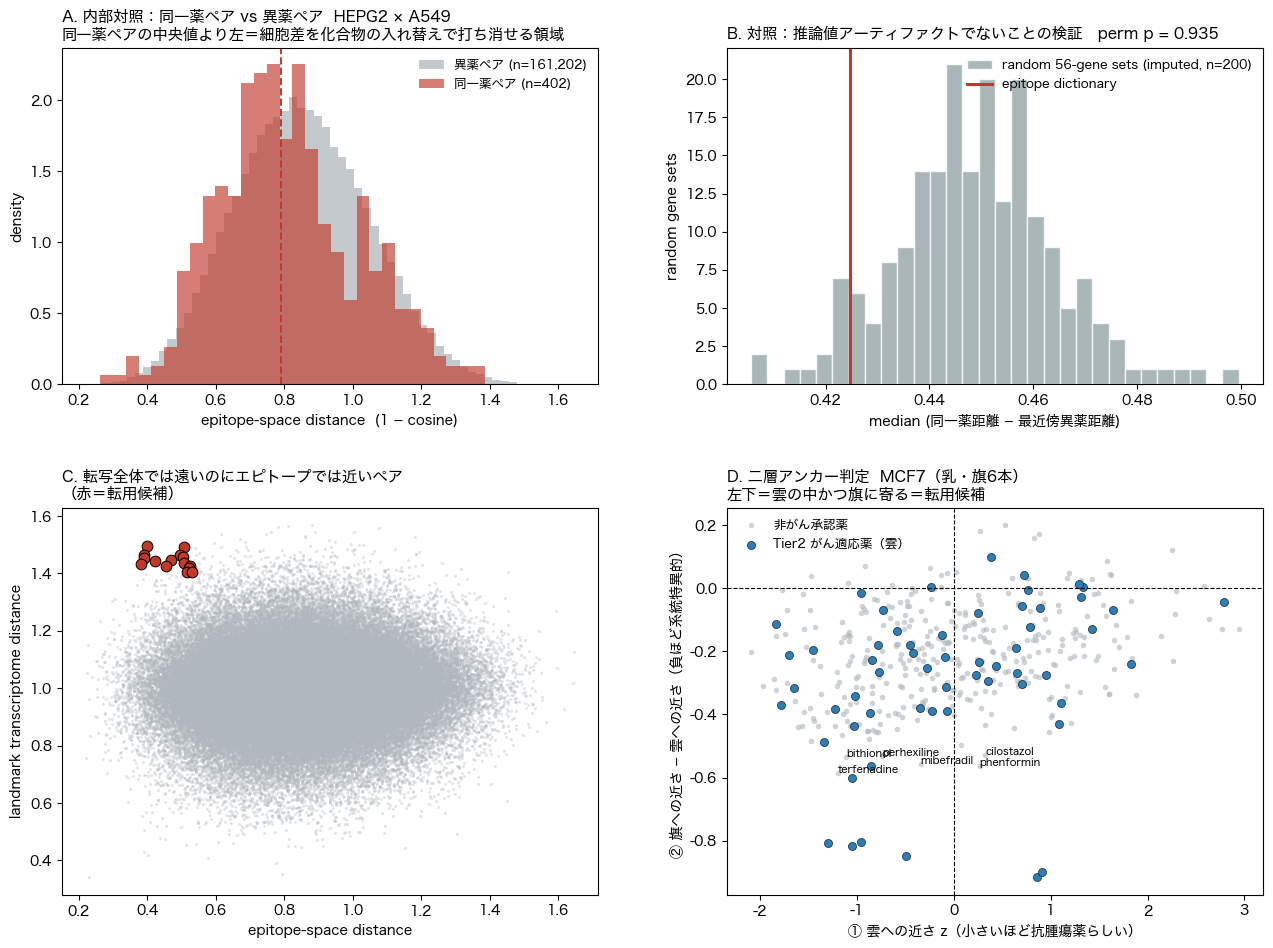

In [14]:
fig = plt.figure(figsize=(15.5, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=.34, wspace=.24)

# A: 同一薬ペア（内部対照） vs 異薬ペア
axA = fig.add_subplot(gs[0, 0])
axA.hist(diff_lb, bins=60, color='#b0b7bd', alpha=.75, density=True, label=f'異薬ペア (n={len(diff_lb):,})')
axA.hist(same_lb, bins=30, color='#c0392b', alpha=.65, density=True, label=f'同一薬ペア (n={len(same_lb)})')
axA.axvline(np.median(same_lb), color='#c0392b', ls='--', lw=1.4)
axA.set_xlabel('epitope-space distance  (1 − cosine)'); axA.set_ylabel('density')
axA.set_title('A. 内部対照：同一薬ペア vs 異薬ペア  HEPG2 × A549\n'
              '同一薬ペアの中央値より左＝細胞差を化合物の入れ替えで打ち消せる領域',
              fontsize=11, loc='left')
axA.legend(fontsize=9, frameon=False)

# B: 対照A ランダム推論遺伝子セット
axB = fig.add_subplot(gs[0, 1])
axB.hist(null, bins=30, color='#95a5a6', alpha=.8, edgecolor='white', lw=.4,
         label=f'random {K}-gene sets (imputed, n={N_PERM})')
axB.axvline(obs, color='#c0392b', lw=2.2, label='epitope dictionary')
axB.set_xlabel('median (同一薬距離 − 最近傍異薬距離)'); axB.set_ylabel('random gene sets')
axB.set_title(f'B. 対照：推論値アーティファクトでないことの検証   perm p = {p:.3f}',
              fontsize=11, loc='left')
axB.legend(fontsize=9, frameon=False)

# C: 対照B landmark距離 vs epitope距離
axC = fig.add_subplot(gs[1, 0])
axC.scatter(res.ep, res.lm, s=5, c='#b0b7bd', alpha=.35, lw=0)
axC.scatter(hits.ep, hits.lm, s=60, facecolor='#c0392b', edgecolor='k', lw=.7, zorder=3)
axC.set_xlabel('epitope-space distance'); axC.set_ylabel('landmark transcriptome distance')
axC.set_title('C. 転写全体では遠いのにエピトープでは近いペア\n（赤＝転用候補）', fontsize=11, loc='left')

# D: 二層アンカー
axD = fig.add_subplot(gs[1, 1])
s = anchor_score('MCF7')
axD.scatter(s.loc[~s.is_onc, 'z_cloud'], s.loc[~s.is_onc, 'flag_minus_cloud'],
            s=16, c='#b0b7bd', alpha=.6, lw=0, label='非がん承認薬')
axD.scatter(s.loc[s.is_onc, 'z_cloud'], s.loc[s.is_onc, 'flag_minus_cloud'],
            s=34, c='#2c7fb8', edgecolor='k', lw=.4, label='Tier2 がん適応薬（雲）')
axD.axhline(0, color='k', lw=.8, ls='--'); axD.axvline(0, color='k', lw=.8, ls='--')
for d in cand.index[:6]:
    axD.annotate(d, (s.loc[d, 'z_cloud'], s.loc[d, 'flag_minus_cloud']), fontsize=7.5)
axD.set_xlabel('① 雲への近さ z（小さいほど抗腫瘍薬らしい）')
axD.set_ylabel('② 旗への近さ − 雲への近さ（負ほど系統特異的）')
axD.set_title('D. 二層アンカー判定  MCF7（乳・旗6本）\n左下＝雲の中かつ旗に寄る＝転用候補',
              fontsize=11, loc='left')
axD.legend(fontsize=9, frameon=False)

plt.tight_layout()
for ext in ('png', 'pdf', 'svg'):
    fig.savefig(f'{FIGDIR}/fig4_cross_lineage_transferability.{ext}', dpi=300, bbox_inches='tight')
print('saved fig4')

## 10. テーブル出力

In [15]:
Ea.to_csv(f'{TABDIR}/epitope_contrast_by_cell_approved.csv')
anchors.to_csv(f'{TABDIR}/fig4_anchor_counts.csv', index=False)
hits.to_csv(f'{TABDIR}/fig4_cross_lineage_hits.csv', index=False)
sw.to_csv(f'{TABDIR}/fig4_swap_partners_hepg2_a549.csv')
print('saved tables')
con.close()

saved tables


## 次にやること

- [ ] 全系統ペア（10細胞 → 45ペア）へ展開。現状は HEPG2×A549 のみ
- [ ] 肝の再現性：HEPG2/HUH7/PHH の共通127薬で、見つかったペアが副株でも再現するか
- [ ] Tier1が1本しかない系統（A375/HT29）は旗の検定力が無い。統合するか除外するか判断
- [ ] hits の MoA 注釈（`lincs_glyco_2nd_paper/inputs/moa_target_master/compound_annotation_master.csv`）
- [ ] wet候補の絞り込み：一致しているエピトープからレクチンを選ぶ（core fucose → AAL/LCA）